# 01 — Analyse Exploratoire des Données (EDA) & Nettoyage

**Objectifs :**
- Charger le dataset brut
- Vérifier la qualité (valeurs manquantes, types)
- Nettoyer et filtrer les outliers
- Explorer les distributions et tendances
- Exporter `dataset_propre.csv`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Chargement du dataset brut

In [2]:
df = pd.read_csv('dataset_complet_final.csv')

print("Shape :", df.shape)
print("\nColonnes :", df.columns.tolist())
df.head()

Shape : (10324, 7)

Colonnes : ['job_title', 'Unnamed: 1', 'location', 'Unnamed: 3', 'seniority_level', 'skills', 'salary']


,job_title,Unnamed: 1,location,Unnamed: 3,seniority_level,skills,salary
0,data scientist,NaN,"Grapevine, TX . Hybrid",NaN,senior,"['spark', 'r', 'python', 'scala', 'machine lea...",150705.0
1,data scientist,NaN,"Fort Worth, TX . Hybrid",NaN,lead,"['spark', 'r', 'python', 'sql', 'machine learn...",118733.0
2,data scientist,NaN,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",NaN,senior,"['aws', 'git', 'python', 'docker', 'sql', 'mac...",127273.0
3,data scientist,NaN,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",NaN,senior,"['sql', 'r', 'python']",153599.5
4,data scientist,NaN,On-site,NaN,NaN,[],171254.5


## 3. Inspection qualité

In [3]:
# Types de données
print("=== Types ===")
print(df.dtypes)

# Valeurs manquantes
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())

# Doublons
print(f"\nDoublons : {df.duplicated().sum()}")

=== Types ===
job_title           object
Unnamed: 1         float64
location            object
Unnamed: 3         float64
seniority_level     object
skills              object
salary             float64
dtype: object

=== Valeurs manquantes ===
job_title              3
Unnamed: 1         10324
location               2
Unnamed: 3         10324
seniority_level       60
skills                13
salary                 0
dtype: int64

Doublons : 11


## 4. Nettoyage des données

- Valeurs manquantes : remplacées par le **mode** (valeur la plus fréquente)
- Lignes sans `location` ou `skills` : **supprimées** (non récupérables)
- Doublons : supprimés

In [4]:
# Remplacement par le mode pour les colonnes textuelles importantes
df['job_title']      = df['job_title'].fillna(df['job_title'].mode()[0])
df['seniority_level']= df['seniority_level'].fillna(df['seniority_level'].mode()[0])

# Suppression des lignes sans localisation ni compétences
df = df.dropna(subset=['location', 'skills'])

# Suppression des doublons
df = df.drop_duplicates()

print("Shape après nettoyage :", df.shape)
print("Valeurs manquantes restantes :")
print(df.isnull().sum())

Shape après nettoyage : (10298, 7)
Valeurs manquantes restantes :
job_title              0
Unnamed: 1         10298
location               0
Unnamed: 3         10298
seniority_level        0
skills                 0
salary                 0
dtype: int64


## 5. Distribution des salaires & traitement des outliers

=== Statistiques salaire ===


count    1.029800e+04
mean     2.616225e+05
std      7.203153e+04
min      7.055000e+03
25%      1.998224e+05
50%      2.950849e+05
75%      3.070598e+05
max      2.739979e+06
Name: salary, dtype: float64

Quantile 99% : 331,498 USD


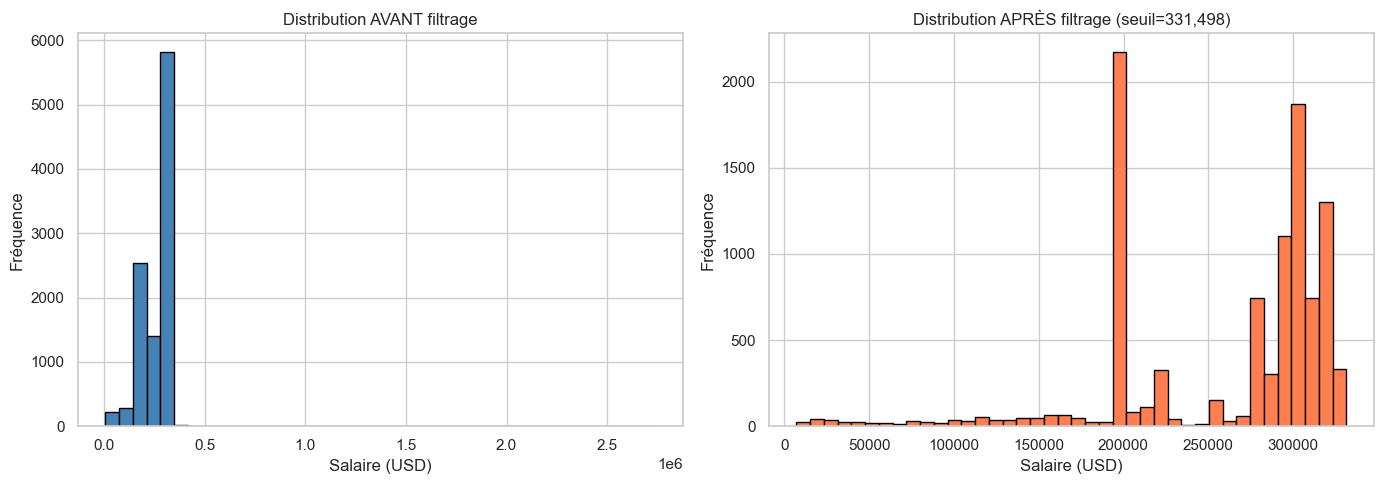

Shape finale : (10201, 7)


In [5]:
# Avant filtrage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['salary'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution AVANT filtrage')
axes[0].set_xlabel('Salaire (USD)')
axes[0].set_ylabel('Fréquence')

# Statistiques descriptives
print("=== Statistiques salaire ===")
print(df['salary'].describe())
print(f"\nQuantile 99% : {df['salary'].quantile(0.99):,.0f} USD")

# Filtrage des outliers (seuil = quantile 99%)
seuil = df['salary'].quantile(0.99)
df = df[df['salary'] <= seuil]

# Après filtrage
df['salary'].hist(bins=40, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title(f'Distribution APRÈS filtrage (seuil={seuil:,.0f})')
axes[1].set_xlabel('Salaire (USD)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()
print("Shape finale :", df.shape)

## 6. Analyse par niveau de séniorité

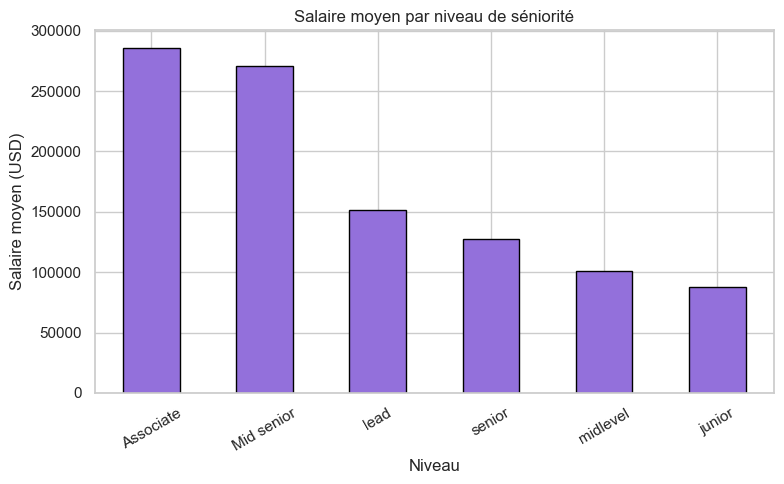

seniority_level
Associate     285920.801301
Mid senior    271097.581216
lead          151262.030435
senior        127461.695652
midlevel      101054.236607
junior         87939.740000
Name: salary, dtype: float64


In [6]:
# Salaire moyen par séniorité
sal_seniority = df.groupby('seniority_level')['salary'].mean().sort_values(ascending=False)

sal_seniority.plot(kind='bar', figsize=(8, 5), color='mediumpurple', edgecolor='black')
plt.title('Salaire moyen par niveau de séniorité')
plt.xlabel('Niveau')
plt.ylabel('Salaire moyen (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print(sal_seniority)

## 7. Top 10 compétences les plus demandées

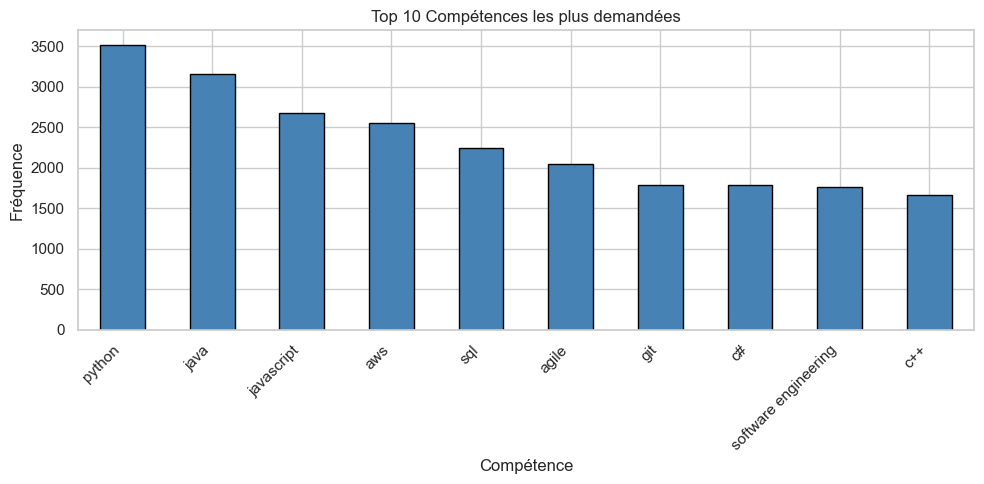

skills
python                  3521
java                    3157
javascript              2674
aws                     2558
sql                     2246
agile                   2044
git                     1794
c#                      1783
software engineering    1761
c++                     1664
Name: count, dtype: int64


In [7]:
# Explosion des skills (séparées par virgule)
skills_series = df['skills'].str.lower().str.split(',').explode().str.strip()
top_skills = skills_series.value_counts().head(10)

top_skills.plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='black')
plt.title('Top 10 Compétences les plus demandées')
plt.xlabel('Compétence')
plt.ylabel('Fréquence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(top_skills)

## 8. Export du dataset propre

In [8]:
df.to_csv('dataset_propre.csv', index=False)
print("✅ dataset_propre.csv sauvegardé —", df.shape)

✅ dataset_propre.csv sauvegardé — (10201, 7)


## Conclusion

| Étape | Résultat |
|-------|----------|
| Valeurs manquantes | Traitées par mode ou suppression |
| Doublons | Supprimés |
| Outliers salaire | Filtrés au quantile 99% |
| Dataset final | Prêt pour modélisation |

➡ Prochain notebook : `02_modeles_classification.ipynb`